# Chapter 3. Parallelization

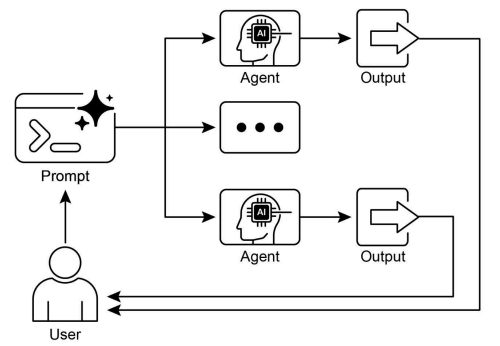

### Core Concept
- **Simultaneous Execution**: Running multiple tasks at the same time instead of one after another.
- **Aggregation**: Parallel steps finish and then a final sequential step combines all the results.

### Why Use It?
- **Speed**: Reduces total execution time by avoiding the "wait time" of sequential steps.
- **Efficiency**: Best for handling high-latency external services like APIs or database queries.
- **Better Performance**: Makes complex agents more responsive and faster for the end user.

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install langchain langchain-community langchain-openai langgraph
```

In [1]:
import os, json
from typing import Optional
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import Runnable, RunnableLambda, RunnablePassthrough, RunnableParallel
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = ChatOpenAI(
    model="glm-5-turbo",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Create helper function to ensure the chain is executed parallelly.

In [3]:
from datetime import datetime

def start_chain(name):
    def wrapper(topic):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[START] {timestamp} {name}")
        return topic
    return wrapper

def end_chain(name):
    def wrapper(topic):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[END]   {timestamp} {name}")
        return topic
    return wrapper

Define three independent chains.

In [4]:
chain_summarize: Runnable = (
    RunnableLambda(start_chain("chain_summarize"))
    | ChatPromptTemplate.from_messages([
        ("system", "Summarize the following topic concisely"),
        ("user", "{topic}")
      ])
    | llm
    | StrOutputParser()
    | RunnableLambda(end_chain("chain_summarize"))
)

chain_question: Runnable = (
    RunnableLambda(start_chain("chain_question"))
    | ChatPromptTemplate.from_messages([
        ("system", "Generate three interesting questions about the following topic:"),
        ("user", "{topic}")
      ])
    | llm
    | StrOutputParser()
    | RunnableLambda(end_chain("chain_question"))
)

chain_terms: Runnable = (
    RunnableLambda(start_chain("chain_terms"))
    | ChatPromptTemplate.from_messages([
        ("system", "Identify 5-10 key terms from the following topic, separated by commas:"),
        ("user", "{topic}")
      ])
    | llm
    | StrOutputParser()
    | RunnableLambda(end_chain("chain_terms"))
)

Build the Parallel + Synthesis Chain.

In [5]:
chain_parallel = RunnableParallel({
    "summary"  : chain_summarize,
    "questions": chain_question,
    "key_terms": chain_terms,
    "topic": RunnablePassthrough()
})

prompt_synthesis = ChatPromptTemplate.from_messages([
    ("system", """
         Based on the following information:
         Summary: {summary}
         Related Question: {questions}
         Key Terms: {key_terms}

         Synthesize a comprehensive answer.
     """),
    ("user", "Original topic: {topic}")
])

Construct the full chain by piping the parallel results directly into the synthesis prompt.

In [6]:
chain = chain_parallel | prompt_synthesis | llm | StrOutputParser()

Test the chain out.

In [7]:
# import asyncio

async def run_parallel(topic: str):
    print(f"\n--- Running Parallel LangChain Example for Topic: '{topic}' ---")
    response = await chain.ainvoke(topic)

    print("\n--- Final Response ---")
    display(Markdown(response))

topic = "The history of space exploration"
await run_parallel(topic)
# asyncio.run(run_parallel(topic))


--- Running Parallel LangChain Example for Topic: 'The history of space exploration' ---
[START] 2026-06-25 13:00:26 chain_summarize
[START] 2026-06-25 13:00:26 chain_question
[START] 2026-06-25 13:00:26 chain_terms
[END]   2026-06-25 13:00:37 chain_terms
[END]   2026-06-25 13:00:57 chain_summarize
[END]   2026-06-25 13:01:06 chain_question

--- Final Response ---


The history of space exploration is far more than a chronological timeline of technological achievements; it is a profound reflection of human psychology, shifting geopolitical landscapes, and our evolving cultural identity. By examining the six key eras of spaceflight through the lens of its most compelling paradoxes, we can understand how humanity transitioned from dreaming of the stars to becoming a permanent orbital species.

**The Foundations and the Spark of Fear**
The journey began in the early 1900s–1940s with pioneers like Robert Goddard and Konstantin Tsiolkovsky, who laid the theoretical and practical groundwork for liquid-fueled rockets. However, this pure scientific curiosity was rapidly overshadowed by Cold War paranoia. The 1950s–1960s ushered in the **Space Race**, a period defined not by a gentle quest for knowledge, but by the existential fear of nuclear annihilation. When the USSR launched the first artificial **Satellite**, **Sputnik**, in 1957, and subsequently sent the first human, **Yuri Gagarin**, into space in 1961, the U.S. viewed it as a dire technological threat. In response, **NASA** accelerated the **Apollo program**, culminating in the triumphant **Moon landing** in 1969. 

**The Paradox of "Lost" Technology**
Yet, this monumental achievement reveals a fascinating paradox: despite landing on the Moon six times, humanity lost the immediate technological capability and manufacturing chains to do it again for nearly half a century. This "lost technology" demonstrates that massive, rapid leaps in progress are often driven by political fear and military urgency rather than sustainable scientific curiosity. Once the geopolitical fear subsided after the U.S. "won" the Space Race, the funding and unified national willpower evaporated. It ultimately took the rise of the Commercial Space Age (2020s–Present) to break this stagnation. Private companies like SpaceX introduced market efficiencies, radically lowering launch costs and replacing political panic with commercial viability, paving the way for NASA's current Artemis program to return humans to the Moon.

**From Enemies to Roommates**
The transition from the 1970s into the 2000s highlights another miraculous shift: how did two superpowers on the brink of mutual destruction become essential partners in the vacuum of space? As the immediate tensions of the 1960s cooled, the 1970s saw a shift toward long-duration stays and robotic exploration, with the USSR launching the first *Salyut* stations and both nations sending out probes like *Viking* and *Voyager*. By the 1980s and 1990s, the U.S. **Space Shuttle** made access to space more routine, acting as a crucial diplomatic bridge. The Shuttle program facilitated the deployment of the Hubble Space Telescope and helped construct the Russian *Mir* station. This gradual thawing of relations through pragmatic, incremental cooperation ultimately culminated in the **International Space Station (ISS)** in the 2000s–2010s. The ISS stands as a testament to the idea that shared scientific goals and the harsh realities of surviving in space can override earthly hostilities.

**The Voyager Probes as Cultural Mirrors**
Even as superpowers learned to cooperate, the robotic missions of the 1970s served a deeper cultural purpose. When NASA launched the Voyager Golden Records in 1977, they were ostensibly creating a time capsule for potential alien life. However, looking back at the specific music, sounds, and images chosen by a small committee of scientists, the record acts as a profound cultural mirror. It reveals the anxieties and hopes of humanity at the height of the Cold War—an era shadowed by the threat of nuclear extinction. The record's inclusion of diverse sounds of Earth, greetings in multiple languages, and classical music was less about communicating with aliens and more about projecting an idealized, peaceful vision of a humanity that was desperately trying to imagine its own survival.

**The Modern Era**
Today, space exploration has entered the Commercial Space Age. The ISS continues to serve as a symbol of unified global research, aided by advanced robotic explorers like the *Curiosity* and *Opportunity* rovers on Mars. Meanwhile, private companies now handle routine orbital launches, freeing government agencies to focus on frontiers like the James Webb Space Telescope and crewed missions to Mars. 

Ultimately, the history of space exploration is a pendulum swing. It began with solitary theorists, was violently propelled into orbit by the fears of the Space Race, softened into the unprecedented diplomacy of the ISS, and has now matured into a sustainable, commercial endeavor. It proves that while fear may get us to the stars, it is cooperation and innovation that will keep us there.